In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

# --- Global styling and constants ---
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18

# Define shared plot colors and legend ordering
COLOR_MAP = {
    '0': '#1f77b4',  # blue
    '1': '#d78e20',  # orange-ish
    '2': '#c459a1',  # magenta
    '3': '#498c41',  # green
}
LEGEND_ORDER = ['QPA 0', 'Theory', 'QPA 1', 'QPA 2', 'QPA 3']

## Figure 5 — Fidelity Overview

### 5a — Absolute Fidelity (unitary_evolved_full_dm)

Saved Figure 5a to: shared_data/5a/figure_5a.pdf


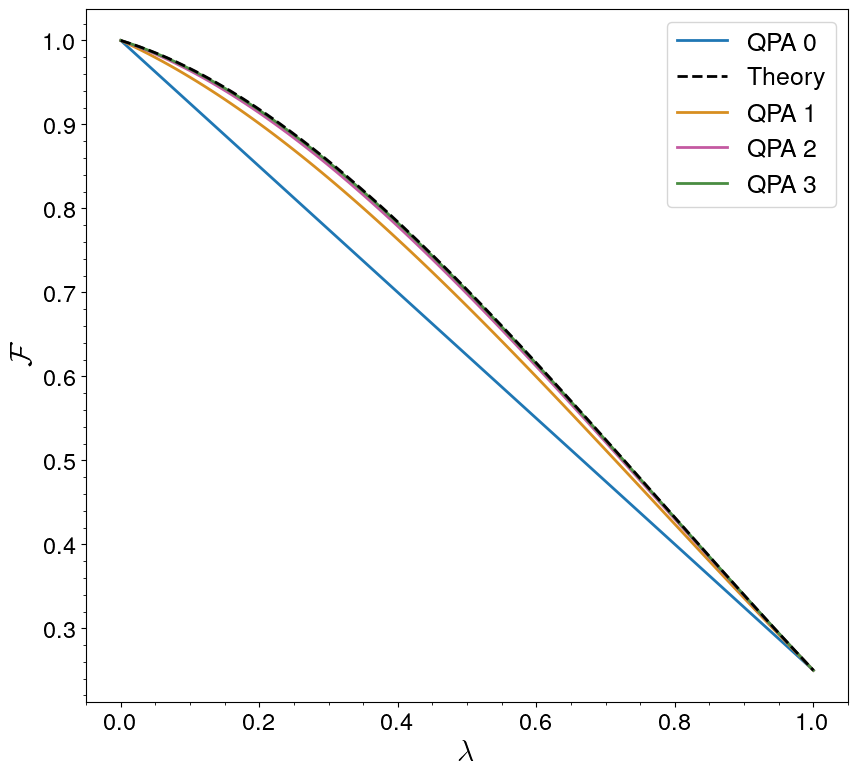

In [11]:
# Imports and setup (kept local for self-contained execution)
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- Configuration ---
k = 2
lambda_min = 0
lambda_max = 1

# Data source (constant path; no task_type variables)
results_folder = 'unitary_evolved_full_dm/simulation_outputs/unitary_evolved_full_dm_k2_lambda_0_1_100'

# Output directory under notebook folder
out_dir = 'shared_data/5a'
os.makedirs(out_dir, exist_ok=True)

# Fallbacks if globals not executed
try:
    COLOR_MAP
except NameError:
    COLOR_MAP = {
        '0': '#1f77b4',
        '1': '#d78e20',
        '2': '#c459a1',
        '3': '#498c41',
    }
try:
    LEGEND_ORDER
except NameError:
    LEGEND_ORDER = ['QPA 0', 'Theory', 'QPA 1', 'QPA 2', 'QPA 3']

# --- Load directories ---
nqpa_dirs = sorted([d for d in os.listdir(results_folder) if os.path.isdir(os.path.join(results_folder, d))])

# === Absolute Fidelity Plot (Figure 5a) ===
plt.figure(figsize=(8.8, 8.0))  # aspect ~ 1.1
ax = plt.gca()

# Plot QPA curves with custom colors
handles = []
labels = []
for nqpa_dir in sorted(nqpa_dirs, key=lambda d: int(d[4])):
    nqpa = nqpa_dir[4]
    color = COLOR_MAP.get(nqpa, '#1f77b4')
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambdas.csv")
    if not os.path.exists(combined_csv):
        continue
    df = pd.read_csv(combined_csv).sort_values("lambda")
    lambda_values = df['lambda'].values
    fidelities = df[f'QPA_{nqpa}'].values
    h, = plt.plot(lambda_values, fidelities, label=f'QPA {nqpa}', color=color, linewidth=2)
    handles.append(h)
    labels.append(f'QPA {nqpa}')

# --- Add theory curve (dashed black) ---
lambda_theory = np.linspace(lambda_min, lambda_max, 300)
theory_curve = (1/8) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory)
h_theory, = plt.plot(lambda_theory, theory_curve, color='black', linestyle='--', linewidth=2, label='Optimal')

# Axes formatting
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.tick_params(which='both', direction='out')
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\mathcal{F}$")
plt.tight_layout()

# Legend text and ordering
handle_map = {lbl: h for lbl, h in zip(labels, handles)}
handle_map['Theory'] = h_theory
ordered = [(name, handle_map[name]) for name in LEGEND_ORDER if name in handle_map]
plt.legend([h for _, h in ordered], [name for name, _ in ordered], frameon=True, loc='upper right')

# Save absolute plot to notebook subdirectory
abs_plot_path = os.path.join(out_dir, 'figure_5a.pdf')
plt.savefig(abs_plot_path)
print('Saved Figure 5a to:', abs_plot_path)
plt.show()

## Panel 6 — Theory

Placeholder for theoretical model plots. TODO:
- Load or define model parameters
- Compute predicted curves
- Render figure(s) with consistent styling

## Panel 7 — Rydberg

Placeholder for Rydberg system plots. TODO:
- Load Rydberg dataset(s)
- Process and normalize as needed
- Plot observables with error bars

Average base fidelity: 0.8201289239384646
0.8201289239384646


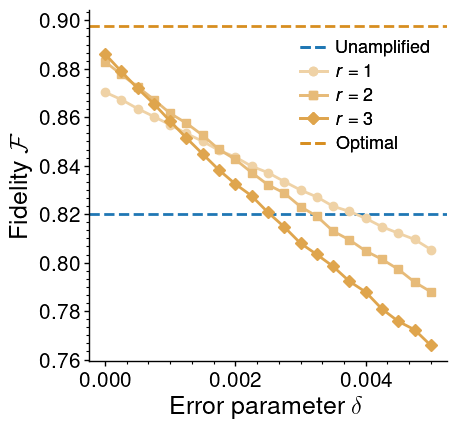

Plot saved to: aer_ryd_estimation/plotting_results/fidelity_125_k4_nshots102400_eps0.0-0.001_s41.svg


In [18]:
import os
import csv
import glob
import re
from collections import defaultdict

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- Enhanced style and axes settings ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

PT_PER_INCH = 72
FIGSIZE = (345 / PT_PER_INCH, 325 / PT_PER_INCH)

font_scale = 1.5
label_fs = int(12 * font_scale)
legend_fs = int(9 * font_scale)
tick_labelsize = int(10 * font_scale)
scaled_markersize = int( 4 * font_scale)  # Consistent with example

# === CONFIGURATION ========================================================
nshots      = 102400
k           = 4
eps_steps   = 41
eps_min     = 0.0
eps_max     = 0.001
eigenstates = 5

base_folder = (
    f"aer_ryd_estimation/simulation_outputs/"
    f"ryd_estimation_{eigenstates**3}_eigenstates_k{k}_shots{nshots}"
    f"_eps{eps_min}-{eps_max}_s{eps_steps}"
)
outfile_svg = (
    f"aer_ryd_estimation/plotting_results/"
    f"fidelity_{eigenstates**3}_k{k}_nshots{nshots}_eps{eps_min}-{eps_max}_s{eps_steps}.svg"
)

datafile           = "aer_ryd_estimation/all_states_5_eigenstates.npz"
exact_state_file   = "aer_ryd_estimation/exact_state.npz"
# ===========================================================================

# === LOAD PROBABILITIES AND STATES =======================================
data         = np.load(datafile, allow_pickle=True)
probs        = data["probs"]
input_states = data["states"]

exact_state  = np.load(exact_state_file, allow_pickle=True)["state"]
# ===========================================================================

# === COMPUTE BASE FIDELITY ===============================================
avg_base_fidelity = 0.0
for prob, state_tuple in zip(probs, input_states):
    q3_input_state = state_tuple[1]                       # third register state
    fid            = abs(np.vdot(q3_input_state, exact_state))**2
    avg_base_fidelity += prob * fid
print("Average base fidelity:", avg_base_fidelity)
print(avg_base_fidelity)
# ===========================================================================

# === LOAD QPA RESULTS, WEIGHT BY PROBS ====================================
fidelity_qpa = defaultdict(list)

for idx, prob in enumerate(probs):
    input_path = os.path.join(base_folder, f"index{idx}")
    if not os.path.exists(input_path):
        print("Missing:", input_path)
        continue

    for folder in os.listdir(input_path):
        if not folder.startswith("nqpa"):
            continue
        nqpa_val  = int(folder.replace("nqpa", ""))
        csv_path  = os.path.join(input_path, folder, "merged_results.csv")
        if not os.path.exists(csv_path):
            print("Missing CSV:", csv_path)
            continue

        with open(csv_path, newline="") as f:
            reader = csv.reader(f)
            header = next(reader)               # "epsilon, fidelity"
            for eps_str, fid_str in reader:
                eps = float(eps_str)
                fid = float(fid_str)
                fidelity_qpa[nqpa_val].append((eps, fid * prob))
# ===========================================================================

# === GROUP & AGGREGATE ====================================================
final_qpa = {}
for nqpa, entries in fidelity_qpa.items():
    buckets = defaultdict(list)
    for eps, w_fid in entries:
        buckets[eps].append(w_fid)
    final_qpa[nqpa] = {eps: sum(vals) for eps, vals in buckets.items()}
# === PLOTTING =============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)

# Base yellow
base_yellow = np.array(mpl.colors.to_rgb("#d78e20"))

# Dashed reference lines
ax.axhline(
    y=avg_base_fidelity,
    linestyle="--",
    color="#1f77b4",
    linewidth=2,
    label="Unamplified"
),

# Lighter variants
colors = [
    base_yellow * 0.4  + np.ones(3) * 0.6,
    base_yellow * 0.6 + np.ones(3) * 0.4,
    base_yellow * 0.8 + np.ones(3) * 0.2
    
]
markers = ['o', 's', 'D']

# Plot amplified curves (r = 1,2,3)
for idx, nqpa in enumerate(sorted(final_qpa.keys())):
    if nqpa == 0:
        continue  # skip unamplified here

    color = colors[idx % len(colors)]
    marker = markers[(nqpa-1) % len(markers)]  # r starts at 1
    eps_list   = sorted(eps for eps in final_qpa[nqpa].keys() if eps <= 0.0005)
    delta_list = [eps * 10 for eps in eps_list]  # Multiply by 10
    fidelities = [final_qpa[nqpa][eps] for eps in eps_list]

    ax.plot(
        delta_list,
        fidelities,
        markersize=scaled_markersize,
        color=color,
        marker=marker,
        linewidth=2,
        label=fr"$r={nqpa}$"
    )



ax.axhline(
    y=0.897822559792652,
    linestyle="--",
    color="#d78e20",
    linewidth=2,
    label="Optimal"
),

# Fine-tune axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)

ax.set_xlabel(r"Error parameter $\delta$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)

# Legend for r (colors)
leg1 = ax.legend(
    loc="upper right",
    fontsize=legend_fs,
    frameon=False,
    title=None,
    borderaxespad=0.5,
    handlelength=1.5,
    handletextpad=0.5,
    labelspacing=0.4,
    borderpad=0.4,
    columnspacing=1.0,
    ncol=1,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(1.0, 0.96)  # Slightly shifted down
    # 1.0 is right edge, 0.96 is just below default (1.0)
    # Adjust as needed for your plot
    # Default is (1.0, 1.0)
    # This moves the legend a little lower
    # Remove or adjust if not desired
)
ax.add_artist(leg1)

# Save and show
fig.tight_layout()
fig.savefig(outfile_svg)
plt.show()

print("Plot saved to:", outfile_svg)

## Panel 8 — Experiments (SI)

Comparison of IBM experiment datasets (k=2, n=5 and n=3) in the same style as the main plot.

Loaded nqpa0 from: three_circuits_ibm_global_sampler/simulation_outputs/three_circuits_ibm_global_sampler_k2_shots1000_lambda0.0-1.0_s20_r500_g0.0_aerfalse_fakefalse/nqpa0/combined_lambda.csv
SVG saved to: three_circuits_ibm_global_sampler/simulation_outputs/three_circuits_ibm_global_sampler_k2_shots1000_lambda0.0-1.0_s20_r500_g0.0_aerfalse_fakefalse/ibm_experiment_panel.svg


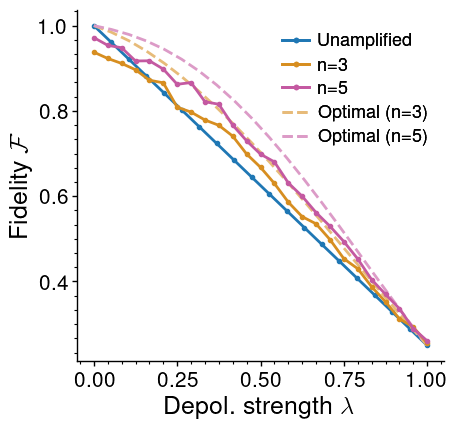

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator

# --- Style to match your other figure ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

PT_PER_INCH = 72
FIGSIZE = (345 / PT_PER_INCH, 325 / PT_PER_INCH)

font_scale = 1.5
label_fs = int(12 * font_scale)
legend_fs = int(9 * font_scale)
tick_labelsize = int(10 * font_scale)
scaled_markersize = int(4 * font_scale)

# --- Parameters for nqpa0 source: must match the working script exactly ---
k = 2
shots = 1000
lambda_min = 0.0
lambda_max = 1.0
lambda_steps = 20
nrandom = 500
gatenoise = 0.0
aer = 'false'
fake = 'false'

custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']

# --- IBM data paths ---
ibm_k2_n5_path = '../shared_data/results_ibm/results_ibm_k2_n5.csv'
ibm_k2_n3_path = '../shared_data/results_ibm/results_ibm_k2_n3.csv'

# --- Folder structure for nqpa0 ---
task_type = 'three_circuits_ibm_global_sampler'
simulation_subfolder = 'simulation_outputs'
simulation_folder = f'{task_type}/{simulation_subfolder}'
filesuffix = f'k{k}_shots{shots}_lambda{lambda_min}-{lambda_max}_s{lambda_steps}_r{nrandom}_g{gatenoise}_aer{aer}_fake{fake}'
results_folder = f'{simulation_folder}/{task_type}_{filesuffix}'
nqpa0_csv = os.path.join(results_folder, 'nqpa0', 'combined_lambda.csv')

# --- Load IBM data ---
ibm_k2_n5 = pd.read_csv(ibm_k2_n5_path)
ibm_k2_n3 = pd.read_csv(ibm_k2_n3_path)

ibm_k2_n5['lambda'] = pd.to_numeric(ibm_k2_n5['lambda'], errors='coerce')
ibm_k2_n5['fidelity'] = pd.to_numeric(ibm_k2_n5['fidelity'], errors='coerce')
ibm_k2_n3['lambda'] = pd.to_numeric(ibm_k2_n3['lambda'], errors='coerce')
ibm_k2_n3['fidelity'] = pd.to_numeric(ibm_k2_n3['fidelity'], errors='coerce')

ibm_k2_n5 = ibm_k2_n5.dropna(subset=['lambda', 'fidelity']).sort_values('lambda')
ibm_k2_n3 = ibm_k2_n3.dropna(subset=['lambda', 'fidelity']).sort_values('lambda')

# --- Load QPA 0 exactly from the same source as your working script ---
sim_lambda = None
sim_fid = None

if os.path.exists(nqpa0_csv):
    sim_df = pd.read_csv(nqpa0_csv).sort_values('lambda')
    sim_df['lambda'] = pd.to_numeric(sim_df['lambda'], errors='coerce')
    sim_df['QPA_0'] = pd.to_numeric(sim_df['QPA_0'], errors='coerce')
    sim_df = sim_df.dropna(subset=['lambda', 'QPA_0'])

    sim_lambda = sim_df['lambda'].to_numpy(dtype=float)
    sim_fid = sim_df['QPA_0'].to_numpy(dtype=float)
    print("Loaded nqpa0 from:", nqpa0_csv)
else:
    print("Warning: nqpa0 CSV not found at:", nqpa0_csv)

# --- Theory x-grid ---
if sim_lambda is not None:
    lambda_theory = np.asarray(sim_lambda, dtype=float)
else:
    lambda_theory = np.linspace(lambda_min, lambda_max, lambda_steps)

# n = 3 theory
theory_n3 = (1 / 8.0) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory)

# n = 5 theory
theory_n5 = (1 / 640.0) * (
    640
    - 96 * lambda_theory
    - 224 * lambda_theory**2
    - 700 * lambda_theory**3
    + 693 * lambda_theory**4
    - 153 * lambda_theory**5
)

# lighter yellow for n = 3 theory, matched to your other style
base_yellow = np.array(mpl.colors.to_rgb("#d78e20"))
light_yellow = base_yellow * 0.6 + np.ones(3) * 0.4   # 
base_purple = np.array(mpl.colors.to_rgb("#c459a1"))
light_purple = base_purple * 0.6 + np.ones(3) * 0.4   # similar to your example

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)

# QPA 0 (Unamplified)
if sim_lambda is not None and sim_fid is not None:
    h_unamp, = ax.plot(
        sim_lambda,
        sim_fid,
        marker='.',
        markersize=scaled_markersize,
        linewidth=2,
        color=custom_colors[0],
        label="Unamplified"
    )
else:
    h_unamp = None

# n = 3 theory
h_opt3, = ax.plot(
    lambda_theory,
    theory_n3,
    linestyle='--',
    linewidth=2,
    color=light_yellow,
    label="Optimal (n=3)"
)

# n = 5 theory
h_opt5, = ax.plot(
    lambda_theory,
    theory_n5,
    linestyle='--',
    linewidth=2,
    color=light_purple,
    label="Optimal (n=5)"
)

# IBM n = 3
h_n3, = ax.plot(
    ibm_k2_n3['lambda'].to_numpy(dtype=float),
    ibm_k2_n3['fidelity'].to_numpy(dtype=float),
    marker='.',
    linewidth=2,
    color=custom_colors[1],
    label="n=3"
)

# IBM n = 5
h_n5, = ax.plot(
    ibm_k2_n5['lambda'].to_numpy(dtype=float),
    ibm_k2_n5['fidelity'].to_numpy(dtype=float),
    marker='.',
    linewidth=2,
    color=custom_colors[2],
    label="n=5"
)

# --- Axes styling to match your other plot ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)

ax.set_xlabel(r"Depol. strength $\lambda$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)

# --- Custom legend order ---
legend_handles = []
legend_labels = []
if h_unamp is not None:
    legend_handles.append(h_unamp)
    legend_labels.append("Unamplified")
legend_handles.extend([h_n3, h_n5, h_opt3, h_opt5])
legend_labels.extend(["n=3", "n=5", "Optimal (n=3)", "Optimal (n=5)"])

leg = ax.legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    fontsize=legend_fs,
    frameon=False,
    borderaxespad=0.5,
    handlelength=1.5,
    handletextpad=0.5,
    labelspacing=0.4,
    borderpad=0.4,
    columnspacing=1.0,
    ncol=1,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(1.0, 0.98)
)
ax.add_artist(leg)

# --- Save as SVG ---
svg_path = os.path.join(results_folder, 'ibm_experiment_panel.svg')
fig.savefig(svg_path, format='svg')
print('SVG saved to:', svg_path)

fig.tight_layout()
plt.show()
